# Air Quality Analysis: PM2.5 Pollution in the United States (2025)

This project analyzes air pollution data across the United States, focusing on PM2.5 levels and their distribution across states and cities.



Air pollution is a major environmental and public health concern. Fine particulate matter (PM2.5) is especially dangerous because it can penetrate deep into the lungs and bloodstream.

Understanding where pollution is highest can help identify regions at greater risk and support better environmental decision-making.



*Which regions in the United States experience the highest PM2.5 pollution levels, and how is pollution distributed across different locations?*

## Data Source

The dataset used in this project comes from the U.S. Environmental Protection Agency (EPA) Air Quality System.

It contains annual (2025) air pollution measurements across monitoring sites in the United States, including:

- State
- County
- City
- Pollutant type
- Average pollution levels (arithmetic mean)

The dataset was accessed via a CSV file hosted on GitHub to ensure reproducibility.

##Load Data

In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/JaneRah/Capstone_Air_Quality_Analysis_2025/main/annual_air_data_2025.csv"
df = pd.read_csv(url)

df.head()

,State Name,County Name,City Name,CBSA Name,Parameter Name,Units of Measure,Arithmetic Mean,Arithmetic Standard Dev,Observation Count,Observation Percent,Latitude,Longitude
0,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",Ozone,Parts per million,0.045286,0.010770,4141,74,30.497478,-87.880258
1,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",Ozone,Parts per million,0.040849,0.010416,4328,73,30.497478,-87.880258
2,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",Ozone,Parts per million,0.040849,0.010416,4328,73,30.497478,-87.880258
3,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",Ozone,Parts per million,0.040821,0.010550,3071,73,30.497478,-87.880258
4,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",PM2.5 - Local Conditions,Micrograms/cubic meter (LC),6.969204,5.563808,5780,66,30.497478,-87.880258


In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59154 entries, 0 to 59153
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   State Name               59154 non-null  object 
 1   County Name              59154 non-null  object 
 2   City Name                46599 non-null  object 
 3   CBSA Name                53177 non-null  object 
 4   Parameter Name           59154 non-null  object 
 5   Units of Measure         59154 non-null  object 
 6   Arithmetic Mean          59154 non-null  float64
 7   Arithmetic Standard Dev  59154 non-null  float64
 8   Observation Count        59154 non-null  int64  
 9   Observation Percent      59154 non-null  int64  
 10  Latitude                 59154 non-null  float64
 11  Longitude                59154 non-null  float64
dtypes: float64(4), int64(2), object(6)
memory usage: 5.4+ MB


## Data Cleaning

To prepare the dataset for analysis:

- Column names were standardized to lowercase
- Rows with missing pollution values were removed
- Only relevant columns were retained

In [ ]:
df.columns = df.columns.str.lower().str.replace(" ", "_")

df = df.dropna(subset=["arithmetic_mean"])

df.head()

,state_name,county_name,city_name,cbsa_name,parameter_name,units_of_measure,arithmetic_mean,arithmetic_standard_dev,observation_count,observation_percent,latitude,longitude
0,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",Ozone,Parts per million,0.045286,0.010770,4141,74,30.497478,-87.880258
1,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",Ozone,Parts per million,0.040849,0.010416,4328,73,30.497478,-87.880258
2,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",Ozone,Parts per million,0.040849,0.010416,4328,73,30.497478,-87.880258
3,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",Ozone,Parts per million,0.040821,0.010550,3071,73,30.497478,-87.880258
4,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",PM2.5 - Local Conditions,Micrograms/cubic meter (LC),6.969204,5.563808,5780,66,30.497478,-87.880258


## Filtering PM2.5 Data

The dataset contains many pollutants, but this analysis focuses specifically on PM2.5 under local conditions, which represents real-world exposure levels.

In [ ]:
df_pm25 = df[df["parameter_name"] == "PM2.5 - Local Conditions"]

df_pm25.head()

,state_name,county_name,city_name,cbsa_name,parameter_name,units_of_measure,arithmetic_mean,arithmetic_standard_dev,observation_count,observation_percent,latitude,longitude
4,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",PM2.5 - Local Conditions,Micrograms/cubic meter (LC),6.969204,5.563808,5780,66,30.497478,-87.880258
5,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",PM2.5 - Local Conditions,Micrograms/cubic meter (LC),6.942917,3.152118,240,66,30.497478,-87.880258
6,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",PM2.5 - Local Conditions,Micrograms/cubic meter (LC),6.942917,3.152118,240,66,30.497478,-87.880258
7,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",PM2.5 - Local Conditions,Micrograms/cubic meter (LC),6.942917,3.152118,240,66,30.497478,-87.880258
8,Alabama,Baldwin,Fairhope,"Daphne-Fairhope-Foley, AL",PM2.5 - Local Conditions,Micrograms/cubic meter (LC),6.942917,3.152118,240,66,30.497478,-87.880258


###Returns top polluted areas based on average PM2.5 levels.

In [ ]:
def get_top_polluted_areas(df, group_col, top_n=10):
    return (
        df.groupby(group_col)["arithmetic_mean"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
    )

## Most Polluted States



In [ ]:
top_states = get_top_polluted_areas(df_pm25, "state_name")
top_states

,arithmetic_mean
state_name,
Country Of Mexico,11.243000
Texas,10.215790
Arkansas,9.334405
New Mexico,9.213608
Ohio,9.026952
Indiana,8.764713
Illinois,8.737578
Georgia,8.625939
North Dakota,8.488632


###Visualization  States

In [ ]:
import matplotlib.pyplot as plt

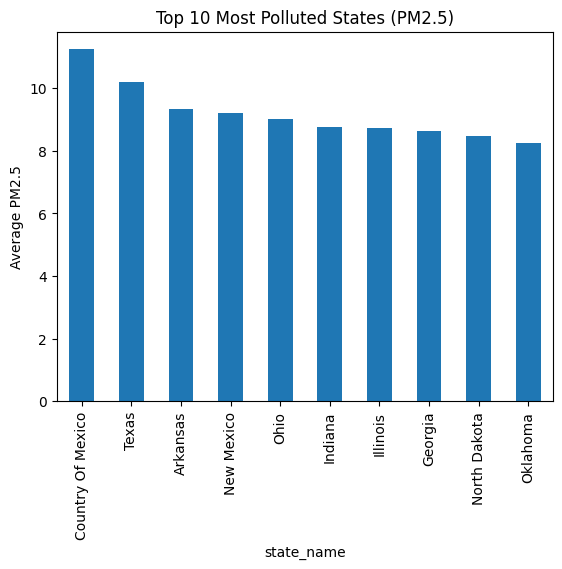

In [ ]:
top_states.plot(kind="bar", title="Top 10 Most Polluted States (PM2.5)")
plt.ylabel("Average PM2.5")
plt.show()

####The results show that PM2.5 pollution is not evenly distributed across states. Some states consistently have higher average pollution levels, indicating regional environmental challenges.

## Most Polluted Cities

In [ ]:
top_cities = get_top_polluted_areas(df_pm25, "city_name")
top_cities

,arithmetic_mean
city_name,
El Paso,21.386867
Clovis,17.268092
Anthony,14.556263
Socorro,14.158018
Ontario,12.755256
Pasadena,12.743103
Los Angeles,12.483864
Pico Rivera,12.426230
Compton,12.392340


###Visualization  Cities  

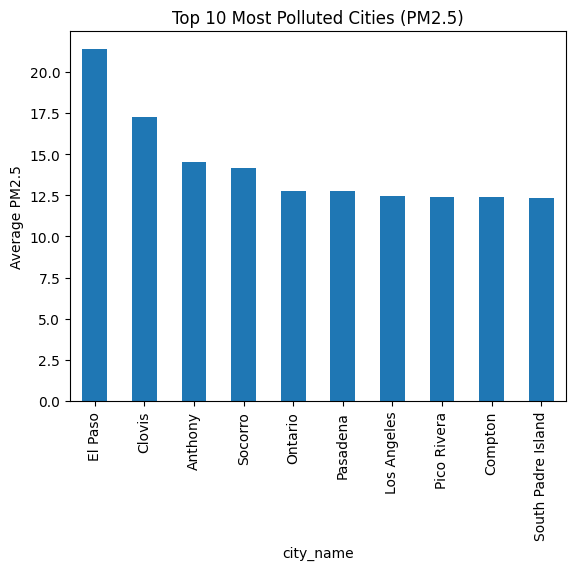

In [ ]:
top_cities.plot(kind="bar", title="Top 10 Most Polluted Cities (PM2.5)")
plt.ylabel("Average PM2.5")
plt.show()

####City-level analysis reveals specific pollution hotspots, showing that air pollution is often concentrated in particular urban areas rather than evenly distributed.

This map shows the geographic distribution of PM2.5 levels, highlighting clusters of higher pollution in specific regions.

In [ ]:
import folium

map_usa = folium.Map(location=[37, -95], zoom_start=5)

for _, row in df_pm25.sample(1000).iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=3,
    ).add_to(map_usa)

map_usa

## Statistical Analysis

To better understand the overall distribution of PM2.5 levels, we examine summary statistics and the distribution of values.

In [ ]:
df_pm25["arithmetic_mean"].describe()

,arithmetic_mean
count,13353.000000
mean,7.400408
std,2.118147
min,0.222925
25%,6.231214
50%,7.364000
75%,8.477358
max,24.550000


##Histogram

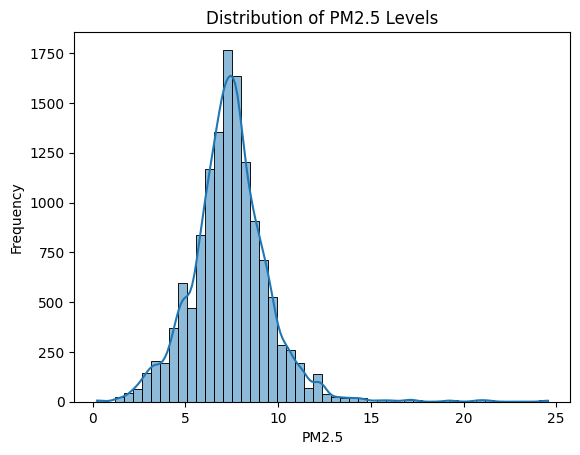

In [ ]:
import seaborn as sns

sns.histplot(df_pm25["arithmetic_mean"], bins=50, kde=True)

plt.title("Distribution of PM2.5 Levels")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")
plt.show()

####The histogram shows that most PM2.5 values fall within a moderate range, with a peak around 6–8. The distribution is right-skewed, meaning that while most areas experience moderate pollution, a smaller number of locations have significantly higher pollution levels.

## Variability of Pollution

We also examine how stable or variable pollution levels are across states.

In [ ]:
state_variability = df_pm25.groupby("state_name")["arithmetic_mean"].std().sort_values(ascending=False).head(10)
state_variability

,arithmetic_mean
state_name,
New Mexico,4.503497
Texas,3.374396
California,2.960481
Arizona,2.404910
Alaska,2.019041
Montana,1.810159
South Dakota,1.766578
Michigan,1.610152
Rhode Island,1.580929


## Conclusion

This analysis shows that PM2.5 pollution in the United States is not evenly distributed.

Most locations experience moderate pollution levels, but certain states and cities have significantly higher concentrations. The right-skewed distribution indicates that extreme pollution levels, while less common, are still an important concern.

These findings suggest that air pollution is concentrated in specific high-risk areas and should be addressed with targeted environmental policies.